# 🧠 Natural Language Processing Practical Handbook in Python

---

Welcome to the **NLP Practical Handbook**! This notebook walks you through Natural Language Processing from the ground up — from raw text cleaning all the way to Transformers and a mini end-to-end project.

### 📚 Table of Contents
1. Introduction to NLP
2. Text Preprocessing
3. Text Representation
4. Text Classification
5. Sentiment Analysis
6. Topic Modeling
7. Word Embeddings
8. Deep Learning for NLP
9. Transformers
10. Mini NLP Project



In [40]:

!pip install nltk spacy scikit-learn transformers torch pandas numpy matplotlib seaborn gensim --quiet
!python -m spacy download en_core_web_sm --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('movie_reviews', quiet=True)



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.4 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


True

---
## Section 1: Introduction to NLP

### 🔍 What is NLP?

**Natural Language Processing (NLP)** is a branch of Artificial Intelligence that enables computers to understand, interpret, and generate human language.

It sits at the intersection of:
- **Linguistics** : structure and meaning of language
- **Computer Science** : algorithms and data structures
- **Machine Learning** : learning patterns from data

### 🌍 Applications of NLP

| Application | Examples |
|---|---|
| Machine Translation | Google Translate, DeepL |
| Sentiment Analysis | Product reviews, social media monitoring |
| Chatbots | Customer support, virtual assistants |
| Text Summarization | News aggregators, document summarization |
| Named Entity Recognition | Information extraction, knowledge graphs |
| Speech Recognition | Siri, Alexa, Google Assistant |
| Question Answering | Search engines, FAQ bots |
| Text Classification | Spam detection, topic categorization |

### 🔄 The NLP Pipeline

```
Raw Text
   ↓
Text Preprocessing  (cleaning, normalization)
   ↓
Tokenization        (splitting into words/sentences)
   ↓
Feature Extraction  (BoW, TF-IDF, Embeddings)
   ↓
Model Training      (ML / Deep Learning)
   ↓
Evaluation & Prediction
```

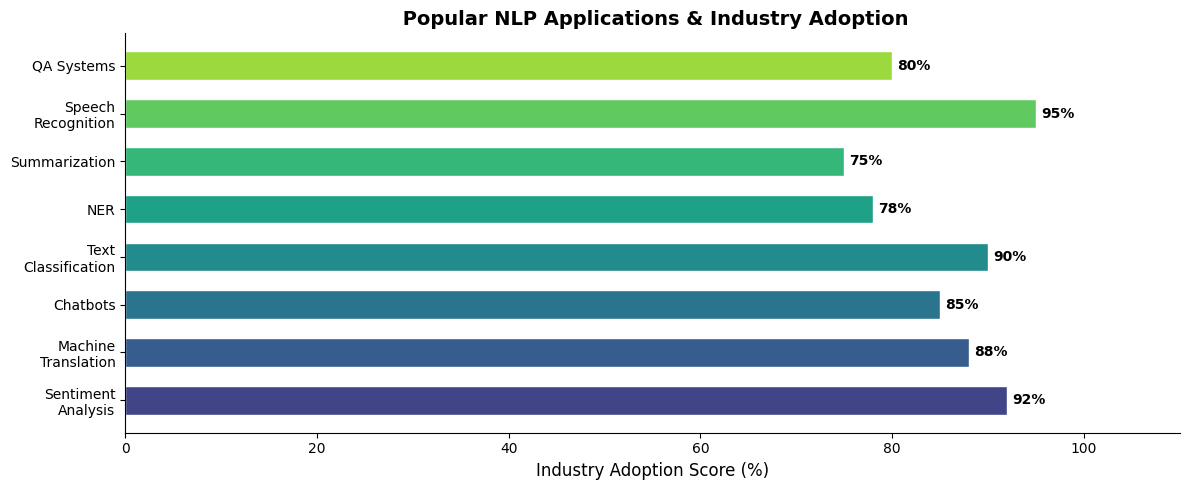

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


applications = [
    'Sentiment\nAnalysis', 'Machine\nTranslation', 'Chatbots',
    'Text\nClassification', 'NER', 'Summarization',
    'Speech\nRecognition', 'QA Systems'
]
scores = [92, 88, 85, 90, 78, 75, 95, 80]
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(applications)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(applications, scores, color=colors, edgecolor='white', height=0.6)

for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Industry Adoption Score (%)', fontsize=12)
ax.set_title(' Popular NLP Applications & Industry Adoption', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 2: Text Preprocessing

Raw text is messy. Before any model can learn from it, we need to **clean and normalise** it.

### Preprocessing Steps
| Step | Description |
|---|---|
| **Lowercasing** | Convert all text to lowercase so `Dog` == `dog` |
| **Remove Punctuation** | Strip `.,!?` etc. |
| **Remove Stopwords** | Drop common words like `the`, `is`, `in` |
| **Tokenization** | Split text into individual tokens (words/sentences) |
| **Stemming** | Reduce word to root form: `running → run` (rule-based) |
| **Lemmatization** | Reduce to dictionary form: `better → good` (vocabulary-aware) |

In [42]:
import re
import string
import nltk
import spacy
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

nlp = spacy.load('en_core_web_sm')


sample_text = """The Quick Brown Fox jumped over the LAZY dog!
NLP is Amazing. It enables computers to understand, interpret,
and generate human language effectively. Running, ran, and runs are all forms of 'run'."""

print('Original Text:')
print(sample_text)


Original Text:
The Quick Brown Fox jumped over the LAZY dog!
NLP is Amazing. It enables computers to understand, interpret,
and generate human language effectively. Running, ran, and runs are all forms of 'run'.


In [43]:

lowercased = sample_text.lower()
print('Lowercased:')
print(lowercased[:120], '...')

Lowercased:
the quick brown fox jumped over the lazy dog!
nlp is amazing. it enables computers to understand, interpret,
and generat ...


In [44]:
# ── Step 2: Remove Punctuation ────────────────────────────────
no_punct = lowercased.translate(str.maketrans('', '', string.punctuation))
# Also remove extra whitespace
no_punct = re.sub(r'\s+', ' ', no_punct).strip()
print(' No Punctuation:')
print(no_punct[:120], '...')

 No Punctuation:
the quick brown fox jumped over the lazy dog nlp is amazing it enables computers to understand interpret and generate hu ...


In [45]:
# ── Step 3: Tokenization (NLTK) ───────────────────────────────
tokens = word_tokenize(no_punct)          # word tokens
sentences = sent_tokenize(sample_text)    # sentence tokens

print(' Word Tokens (first 15):')
print(tokens[:15])
print()
print('   Sentence Tokens:')
for i, s in enumerate(sentences, 1):
    print(f'   [{i}] {s}')

 Word Tokens (first 15):
['the', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'lazy', 'dog', 'nlp', 'is', 'amazing', 'it', 'enables', 'computers']

   Sentence Tokens:
   [1] The Quick Brown Fox jumped over the LAZY dog!
   [2] NLP is Amazing.
   [3] It enables computers to understand, interpret,
and generate human language effectively.
   [4] Running, ran, and runs are all forms of 'run'.


In [46]:
# step 4: Remove Stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]

print('After Stopword Removal:')
print(f'   Before: {len(tokens)} tokens → After: {len(filtered_tokens)} tokens')
print('   Kept tokens:', filtered_tokens)

After Stopword Removal:
   Before: 32 tokens → After: 21 tokens
   Kept tokens: ['quick', 'brown', 'fox', 'jumped', 'lazy', 'dog', 'nlp', 'amazing', 'enables', 'computers', 'understand', 'interpret', 'generate', 'human', 'language', 'effectively', 'running', 'ran', 'runs', 'forms', 'run']


In [47]:
# step 5: Stemming 
stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in filtered_tokens]

print(' Stemming (Porter Stemmer):')
stem_df = pd.DataFrame({'Original': filtered_tokens, 'Stemmed': stemmed})
print(stem_df.to_string(index=False))

 Stemming (Porter Stemmer):
   Original    Stemmed
      quick      quick
      brown      brown
        fox        fox
     jumped       jump
       lazy       lazi
        dog        dog
        nlp        nlp
    amazing       amaz
    enables      enabl
  computers     comput
 understand understand
  interpret  interpret
   generate      gener
      human      human
   language    languag
effectively     effect
    running        run
        ran        ran
       runs        run
      forms       form
        run        run


In [48]:
# Step 6: Lemmatization (NLTK + SpaCy) 

# NLTK lemmatization
lemmatizer = WordNetLemmatizer()
nltk_lemmas = [lemmatizer.lemmatize(w, pos='v') for w in filtered_tokens]

# SpaCy lemmatization (more accurate — context-aware)
doc = nlp(no_punct)
spacy_lemmas = [(token.text, token.lemma_, token.pos_) for token in doc
                if not token.is_stop and not token.is_punct and token.text.strip()]

print('6️⃣  SpaCy Lemmatization (token → lemma, POS):')
lemma_df = pd.DataFrame(spacy_lemmas, columns=['Token', 'Lemma', 'POS'])
print(lemma_df.to_string(index=False))

6️⃣  SpaCy Lemmatization (token → lemma, POS):
      Token       Lemma  POS
      quick       quick  ADJ
      brown       brown  ADJ
        fox         fox NOUN
     jumped        jump VERB
       lazy        lazy  ADJ
        dog         dog NOUN
        nlp         nlp NOUN
    amazing     amazing  ADJ
    enables      enable VERB
  computers    computer NOUN
 understand  understand VERB
  interpret   interpret VERB
   generate    generate VERB
      human       human  ADJ
   language    language NOUN
effectively effectively  ADV
    running         run VERB
        ran         run VERB
       runs         run NOUN
      forms        form NOUN
        run         run NOUN


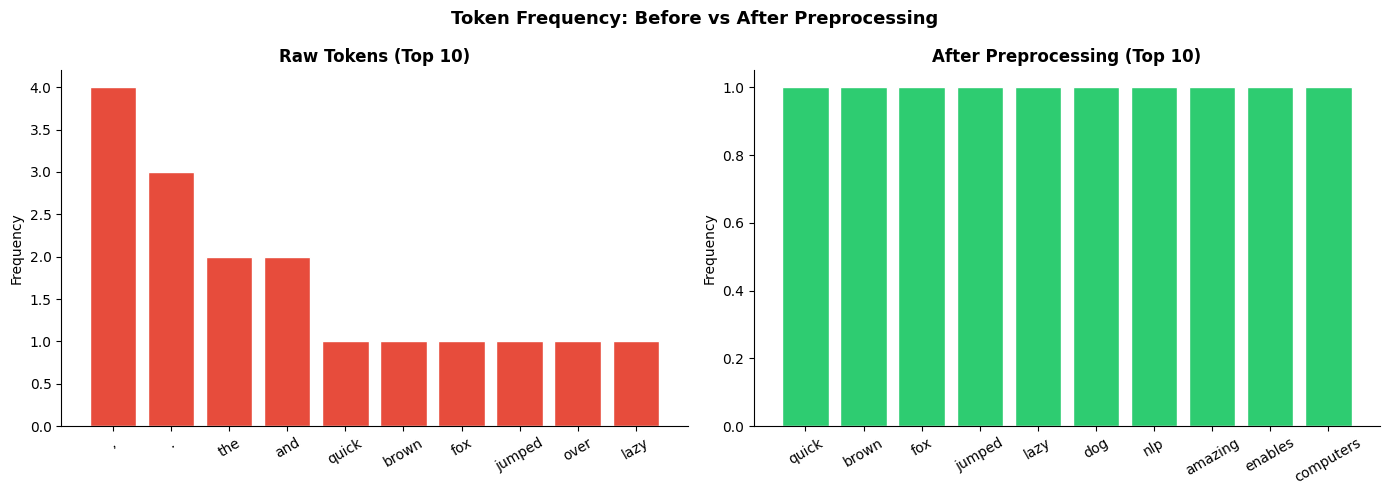

In [49]:
# Visualise: Token frequency before vs after preprocessing 
import matplotlib.pyplot as plt
from collections import Counter

raw_tokens = word_tokenize(sample_text.lower())
raw_freq = Counter(raw_tokens).most_common(10)
clean_freq = Counter(filtered_tokens).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
    axes,
    [raw_freq, clean_freq],
    ['Raw Tokens (Top 10)', 'After Preprocessing (Top 10)'],
    ['#e74c3c', '#2ecc71']
):
    words, counts = zip(*data)
    ax.bar(words, counts, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Token Frequency: Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3: Text Representation

Machine learning models need **numbers**, not words. Text representation converts text into numerical vectors.

### Methods Covered
| Method | Description |
|---|---|
| **Bag of Words (BoW)** | Count occurrences of each word; ignores order |
| **Count Vectorizer** | Scikit-learn BoW implementation |
| **TF-IDF** | Down-weights common words, up-weights rare informative ones |
| **N-grams** | Captures word sequences (bigrams, trigrams) |

> **TF-IDF formula:**  
> `TF-IDF(t, d) = TF(t, d) × log(N / df(t))`  
> Where `N` = total documents, `df(t)` = docs containing term `t`

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# sample corpus 
corpus = [
    "I love natural language processing",
    "NLP is a fascinating field of AI",
    "I love machine learning and AI",
    "Deep learning powers modern NLP",
    "Natural language understanding is hard"
]

print('Corpus:')
for i, doc in enumerate(corpus, 1):
    print(f'  D{i}: {doc}')

Corpus:
  D1: I love natural language processing
  D2: NLP is a fascinating field of AI
  D3: I love machine learning and AI
  D4: Deep learning powers modern NLP
  D5: Natural language understanding is hard


In [51]:
# Bag of Words / Count Vectorizer
count_vec = CountVectorizer()
bow_matrix = count_vec.fit_transform(corpus)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vec.get_feature_names_out(),
    index=[f'D{i+1}' for i in range(len(corpus))]
)

print(' Bag of Words Matrix:')
print(bow_df)
print(f'\nVocabulary size: {len(count_vec.vocabulary_)} unique tokens')

 Bag of Words Matrix:
    ai  and  deep  fascinating  field  hard  is  language  learning  love  \
D1   0    0     0            0      0     0   0         1         0     1   
D2   1    0     0            1      1     0   1         0         0     0   
D3   1    1     0            0      0     0   0         0         1     1   
D4   0    0     1            0      0     0   0         0         1     0   
D5   0    0     0            0      0     1   1         1         0     0   

    machine  modern  natural  nlp  of  powers  processing  understanding  
D1        0       0        1    0   0       0           1              0  
D2        0       0        0    1   1       0           0              0  
D3        1       0        0    0   0       0           0              0  
D4        0       1        0    1   0       1           0              0  
D5        0       0        1    0   0       0           0              1  

Vocabulary size: 18 unique tokens


📊 TF-IDF Matrix (rounded to 3 decimals):
       ai    and   deep  fascinating  field   hard     is  language  learning  \
D1  0.000  0.000  0.000        0.000  0.000  0.000  0.000     0.470     0.000   
D2  0.363  0.000  0.000        0.449  0.449  0.000  0.363     0.000     0.000   
D3  0.406  0.503  0.000        0.000  0.000  0.000  0.000     0.000     0.406   
D4  0.000  0.000  0.482        0.000  0.000  0.000  0.000     0.000     0.389   
D5  0.000  0.000  0.000        0.000  0.000  0.503  0.406     0.406     0.000   

     love  machine  modern  natural    nlp     of  powers  processing  \
D1  0.470    0.000   0.000    0.470  0.000  0.000   0.000       0.582   
D2  0.000    0.000   0.000    0.000  0.363  0.449   0.000       0.000   
D3  0.406    0.503   0.000    0.000  0.000  0.000   0.000       0.000   
D4  0.000    0.000   0.482    0.000  0.389  0.000   0.482       0.000   
D5  0.000    0.000   0.000    0.406  0.000  0.000   0.000       0.000   

    understanding  
D1          0

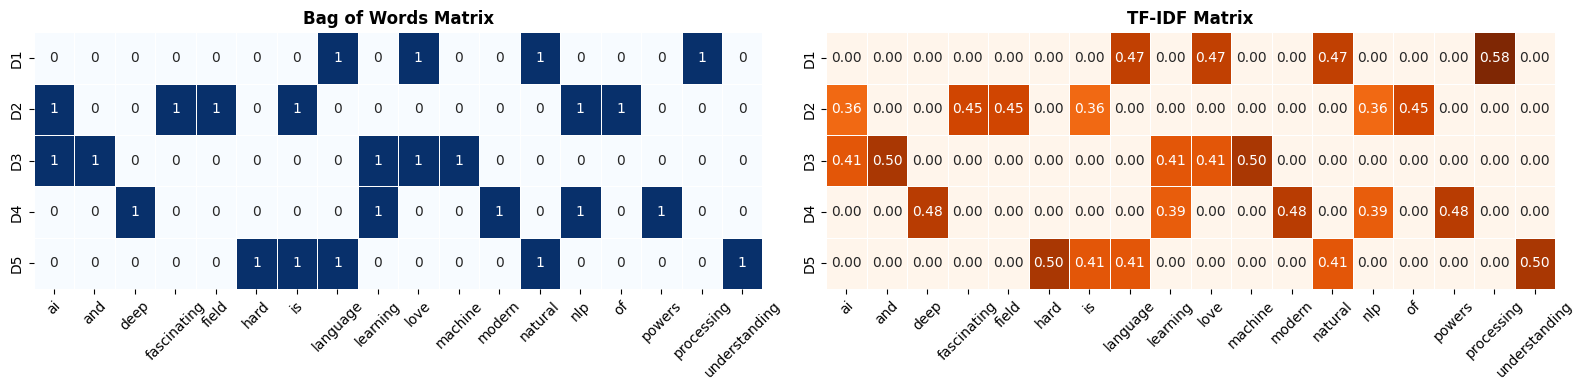

In [52]:
# TF-IDF 
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=tfidf_vec.get_feature_names_out(),
    index=[f'D{i+1}' for i in range(len(corpus))]
)

print('📊 TF-IDF Matrix (rounded to 3 decimals):')
print(tfidf_df)

# Heatmap 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(bow_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, cbar=False)
axes[0].set_title('Bag of Words Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(tfidf_df, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
            linewidths=0.5, cbar=False)
axes[1].set_title('TF-IDF Matrix', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [53]:
#  N-grams
# ngram_range=(2,2) → only bigrams
bigram_vec = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vec.fit_transform(corpus)

bigram_df = pd.DataFrame(
    bigram_matrix.toarray(),
    columns=bigram_vec.get_feature_names_out(),
    index=[f'D{i+1}' for i in range(len(corpus))]
)

print(' Bigram (2-gram) Matrix:')
print(bigram_df)
print('\n Bigrams capture word pairs — useful for phrases like "natural language"')

 Bigram (2-gram) Matrix:
    and ai  deep learning  fascinating field  field of  is fascinating  \
D1       0              0                  0         0               0   
D2       0              0                  1         1               1   
D3       1              0                  0         0               0   
D4       0              1                  0         0               0   
D5       0              0                  0         0               0   

    is hard  language processing  language understanding  learning and  \
D1        0                    1                       0             0   
D2        0                    0                       0             0   
D3        0                    0                       0             1   
D4        0                    0                       0             0   
D5        1                    0                       1             0   

    learning powers  love machine  love natural  machine learning  modern nlp  \
D1  

---
## Section 4: Text Classification

**Text Classification** assigns a predefined category to a text document.

### Models
- **Logistic Regression** : fast, strong baseline for text
- **Naive Bayes** : probabilistic, works well with sparse features
- **Support Vector Machine (SVM)** : great for high-dimensional text

### Dataset
We'll use **NLTK's Movie Reviews** dataset (2,000 reviews: positive/negative).

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import movie_reviews
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix, classification_report)

# load dataset 
docs = [(movie_reviews.raw(fileid), category)
        for category in movie_reviews.categories()
        for fileid in movie_reviews.fileids(category)]

import random
random.seed(42)
random.shuffle(docs)

texts, labels = zip(*docs)
df = pd.DataFrame({'text': texts, 'label': labels})

print(f'Dataset loaded: {len(df)} reviews')
print(df['label'].value_counts())
print('\nSample review (truncated):')
print(df['text'].iloc[0][:300], '...')

Dataset loaded: 2000 reviews
label
neg    1000
pos    1000
Name: count, dtype: int64

Sample review (truncated):
mr . bean , a bumbling security guard from england is sent to la to help with the grandiose homecoming of a masterpiece american painting . 
the first two words should have said enough to let you know what occurs during bean's trip to la , but if they didn't look out because you are in for a rather  ...


In [55]:
# Feature Extraction + Train/Test Split 
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X = tfidf.fit_transform(df['text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Feature dimensions: {X_train.shape[1]}')

# train 3 classifiers 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         MultinomialNB(),
    'SVM (LinearSVC)':     LinearSVC(random_state=42, max_iter=2000)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label='pos'),
        'recall':    recall_score(y_test, y_pred, pos_label='pos'),
        'f1':        f1_score(y_test, y_pred, pos_label='pos')
    }
    print(f' {name} trained')

Train size: 1600 | Test size: 400
Feature dimensions: 5000
 Logistic Regression trained
 Naive Bayes trained
 SVM (LinearSVC) trained


In [56]:
#  evaluation: Metrics Table 
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}"
    }
    for name, r in results.items()
})

print('Evaluation Metrics:')
print(metrics_df)

Evaluation Metrics:
          Logistic Regression Naive Bayes SVM (LinearSVC)
Accuracy               0.8075      0.7850          0.8500
Precision              0.7943      0.8202          0.8365
Recall                 0.8300      0.7300          0.8700
F1-Score               0.8117      0.7725          0.8529


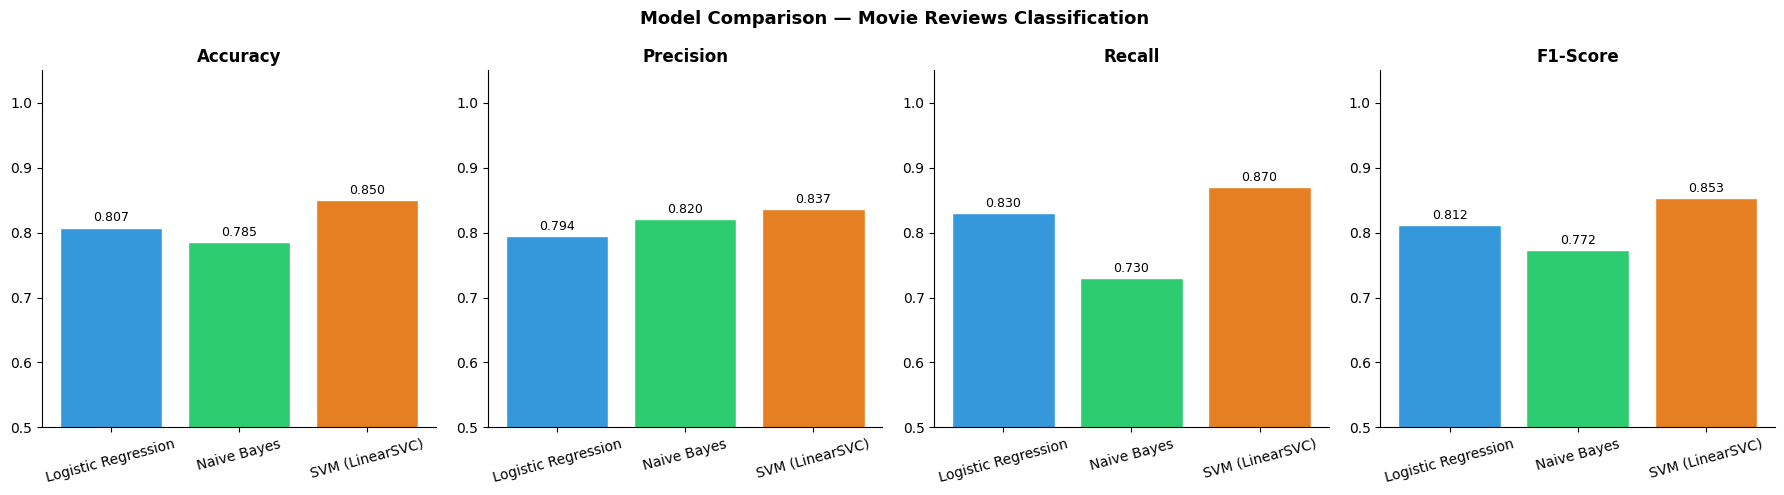

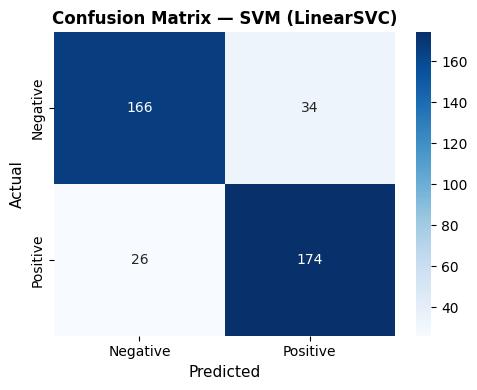


 Classification Report (SVM):
              precision    recall  f1-score   support

         neg       0.86      0.83      0.85       200
         pos       0.84      0.87      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [57]:
# Visualisation
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metric_names = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e67e22']
model_names = list(results.keys())

for ax, metric, label in zip(axes, metric_names, metric_labels):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, values, color=colors, edgecolor='white')
    ax.set_ylim(0.5, 1.05)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison — Movie Reviews Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#  Confusion Matrix for best model (SVM) 
best_name = 'SVM (LinearSVC)'
cm = confusion_matrix(y_test, results[best_name]['y_pred'], labels=['neg', 'pos'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n Classification Report (SVM):')
print(classification_report(y_test, results[best_name]['y_pred']))

---
## Section 5: Sentiment Analysis

**Sentiment Analysis** (Opinion Mining) determines the emotional tone of text: **Positive**, **Negative**, or **Neutral**.

### Approaches
1. **Lexicon-based** : uses word sentiment dictionaries (VADER)
2. **ML-based** : trained classifiers (what we built in Section 4)
3. **Deep learning / Transformers** (Section 9)

We'll use **VADER** (Valence Aware Dictionary and sEntiment Reasoner) — fast and effective for social media/short text.

In [58]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sia = SentimentIntensityAnalyzer()

#  sample sentences
reviews = [
    "This movie was absolutely fantastic! I loved every minute.",
    "Terrible film. Complete waste of time and money.",
    "It was okay, nothing special but not bad either.",
    "The acting was superb but the plot was confusing.",
    "Outstanding cinematography! A true masterpiece of cinema.",
    "I fell asleep halfway through. So boring!",
    "A decent watch for a lazy Sunday afternoon.",
    "Absolutely mind-blowing! Cannot recommend it enough!!!"
]

# VADER Scores
results = []
for review in reviews:
    scores = sia.polarity_scores(review)
    sentiment = ('Positive' if scores['compound'] >= 0.05
                 else 'Negative' if scores['compound'] <= -0.05
                 else 'Neutral')
    results.append({
        'Review':    review[:55] + '...',
        'Negative':  scores['neg'],
        'Neutral':   scores['neu'],
        'Positive':  scores['pos'],
        'Compound':  scores['compound'],
        'Sentiment': sentiment
    })

sent_df = pd.DataFrame(results)
print(sent_df[['Review', 'Compound', 'Sentiment']].to_string(index=False))

                                                    Review  Compound Sentiment
This movie was absolutely fantastic! I loved every minu...    0.8542  Positive
       Terrible film. Complete waste of time and money....   -0.7096  Negative
       It was okay, nothing special but not bad either....    0.5568  Positive
      The acting was superb but the plot was confusing....    0.0516  Positive
Outstanding cinematography! A true masterpiece of cinem...    0.9041  Positive
              I fell asleep halfway through. So boring!...   -0.4376  Negative
            A decent watch for a lazy Sunday afternoon....   -0.3612  Negative
 Absolutely mind-blowing! Cannot recommend it enough!!!...   -0.5487  Negative


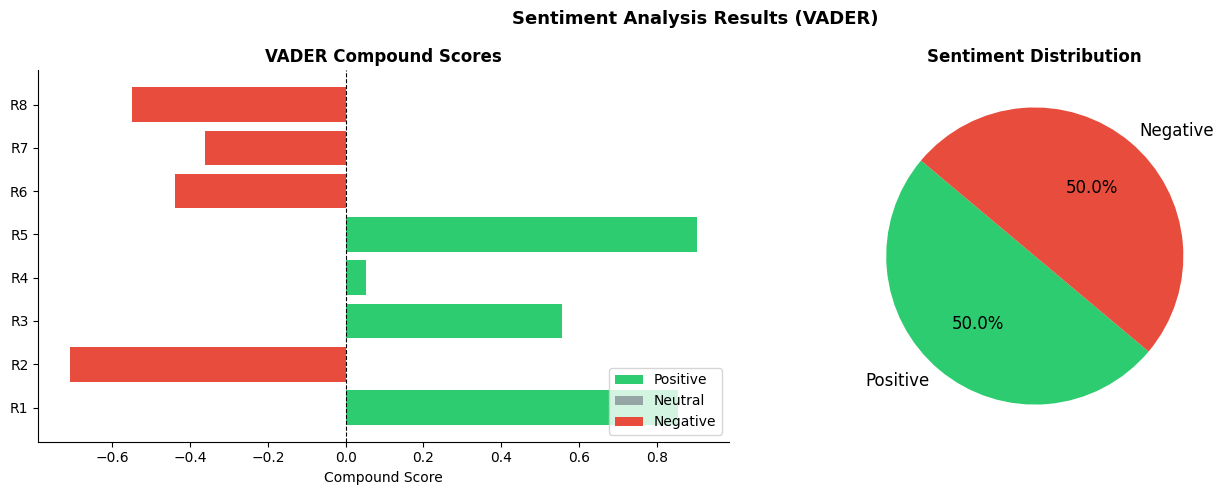

In [59]:
# Visualisation 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compound score bar chart
colors_map = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
bar_colors = [colors_map[s] for s in sent_df['Sentiment']]
axes[0].barh(range(len(sent_df)), sent_df['Compound'], color=bar_colors)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_yticks(range(len(sent_df)))
axes[0].set_yticklabels([f'R{i+1}' for i in range(len(sent_df))])
axes[0].set_xlabel('Compound Score')
axes[0].set_title('VADER Compound Scores', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Positive'),
                   Patch(facecolor='#95a5a6', label='Neutral'),
                   Patch(facecolor='#e74c3c', label='Negative')]
axes[0].legend(handles=legend_elements, loc='lower right')

# Sentiment distribution pie chart
sentiment_counts = sent_df['Sentiment'].value_counts()
pie_colors = [colors_map[s] for s in sentiment_counts.index]
axes[1].pie(sentiment_counts, labels=sentiment_counts.index,
            autopct='%1.1f%%', colors=pie_colors,
            startangle=140, textprops={'fontsize': 12})
axes[1].set_title('Sentiment Distribution', fontweight='bold')

plt.suptitle('Sentiment Analysis Results (VADER)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Topic Modeling

**Topic Modeling** is an unsupervised technique to discover hidden themes (topics) in a collection of documents.

### Latent Dirichlet Allocation (LDA)
LDA assumes:
- Each **document** is a mixture of topics
- Each **topic** is a distribution over words

```
Document → [30% Sports, 50% Politics, 20% Tech]
Topic 'Sports' → [ball: 0.1, game: 0.08, player: 0.07 ...]
```

In [60]:
# Section 6 — Topic Modeling with LDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# sample corpus (5 topics: tech, sports, politics, health, environment)
documents = [
    "Machine learning algorithms are revolutionizing artificial intelligence and data science",
    "Python programming language is widely used in data analysis and machine learning",
    "Neural networks and deep learning power modern computer vision applications",
    "The football team won the championship after an incredible season of games",
    "Basketball players train hard every day to improve their athletic performance",
    "The Olympic games feature athletes competing in swimming running and cycling",
    "Government elections and political campaigns dominate the news this year",
    "Parliament voted on new legislation affecting economic policy and taxes",
    "The president announced new foreign policy initiatives at the summit meeting",
    "Doctors recommend regular exercise and healthy diet to prevent heart disease",
    "New medical research shows promising results for cancer treatment therapies",
    "Mental health awareness and psychological wellbeing are increasingly important",
    "Climate change and global warming threaten biodiversity and natural ecosystems",
    "Renewable energy solar wind and water power can reduce carbon emissions",
    "Environmental pollution affects air quality water resources and public health"
]

# Vectorize with CountVectorizer
vectorizer = CountVectorizer(stop_words='english', max_df=0.95, min_df=1)
doc_term_matrix = vectorizer.fit_transform(documents)

# Fit LDA 
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=20
)
lda.fit(doc_term_matrix)

# Display Topics
feature_names = vectorizer.get_feature_names_out()
topic_labels = ['🤖 Technology', '⚽ Sports', '🏛️ Politics', '🏥 Health', '🌿 Environment']

print('🗂️ Discovered Topics and Top Words:')

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f'\nTopic {topic_idx + 1} {topic_labels[topic_idx]}:')
    print('  ' + ' | '.join(top_words))

🗂️ Discovered Topics and Top Words:

Topic 1 🤖 Technology:
  new | policy | regular | recommend | healthy | heart | exercise | prevent | doctors | disease

Topic 2 ⚽ Sports:
  public | pollution | resources | quality | affects | air | environmental | widely | language | used

Topic 3 🏛️ Politics:
  data | machine | therapies | treatment | promising | research | results | shows | medical | cancer

Topic 4 🏥 Health:
  water | health | renewable | wind | reduce | emissions | energy | solar | carbon | day

Topic 5 🌿 Environment:
  learning | games | power | vision | neural | modern | applications | networks | deep | computer


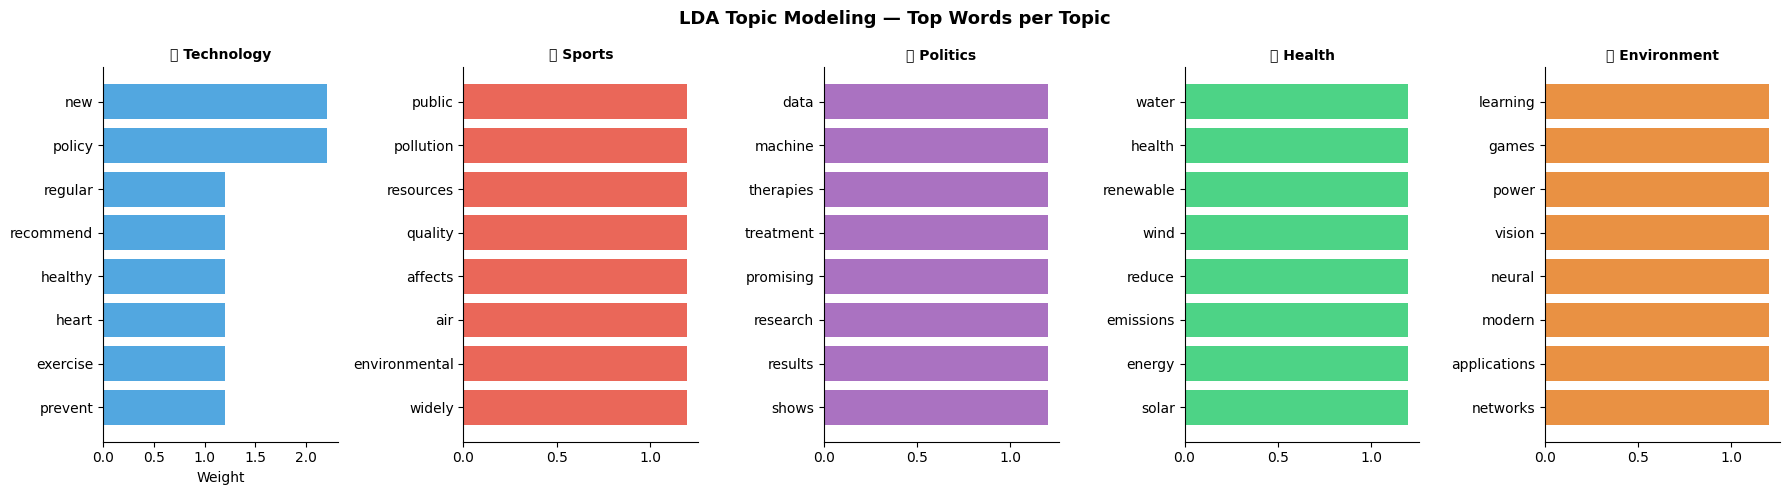

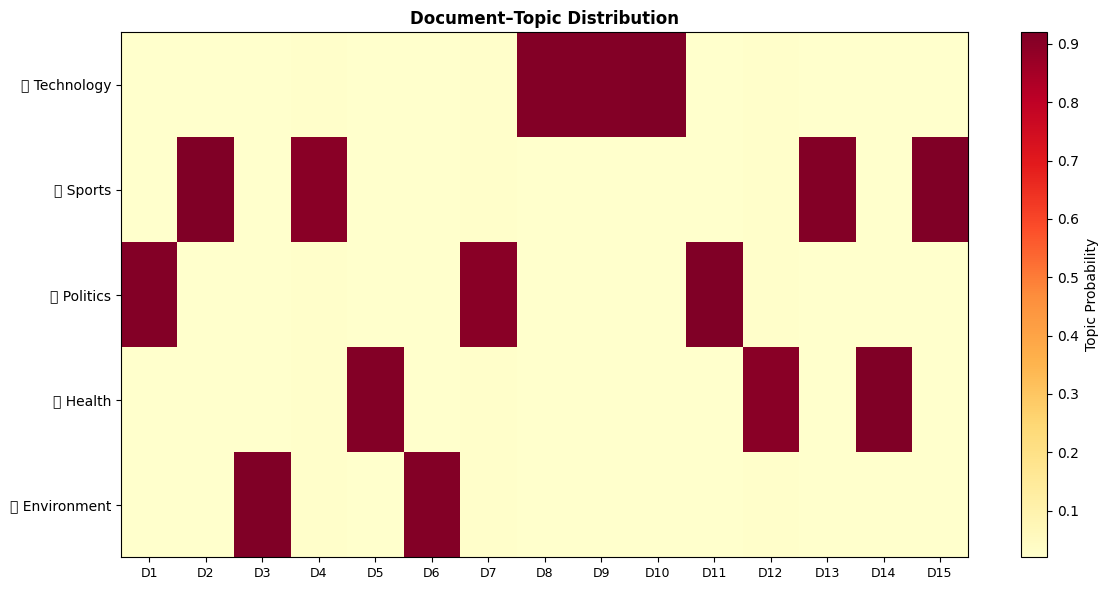

In [61]:
#  Visualise Topics 
fig, axes = plt.subplots(1, n_topics, figsize=(18, 5))
topic_colors = ['#3498db', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

for topic_idx, (ax, color) in enumerate(zip(axes, topic_colors)):
    topic = lda.components_[topic_idx]
    top_idx = topic.argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    top_weights = topic[top_idx]

    ax.barh(top_words[::-1], top_weights[::-1], color=color, alpha=0.85)
    ax.set_title(topic_labels[topic_idx], fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if topic_idx == 0:
        ax.set_xlabel('Weight')

plt.suptitle('LDA Topic Modeling — Top Words per Topic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#Document-Topic distribution
doc_topics = lda.transform(doc_term_matrix)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(doc_topics.T, aspect='auto', cmap='YlOrRd')
ax.set_yticks(range(n_topics))
ax.set_yticklabels(topic_labels, fontsize=10)
ax.set_xticks(range(len(documents)))
ax.set_xticklabels([f'D{i+1}' for i in range(len(documents))], fontsize=9)
ax.set_title('Document–Topic Distribution', fontweight='bold')
plt.colorbar(im, ax=ax, label='Topic Probability')
plt.tight_layout()
plt.show()

---
## Section 7: Word Embeddings

**Word Embeddings** represent words as dense vectors in a continuous vector space where semantically similar words are close together.

### Why Embeddings?
- BoW ignores word meaning and context
- Embeddings capture semantic relationships: `king - man + woman ≈ queen`

### Types
| Method | Description |
|---|---|
| **Word2Vec** | Neural network trained on local context windows (CBOW / Skip-gram) |
| **GloVe** | Global co-occurrence statistics |
| **FastText** | Subword embeddings — handles OOV words |
| **BERT embeddings** | Contextual — same word, different embeddings per context |

In [62]:
# Section 7 — Word Embeddings with Gensim Word2Vec

import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Training corpus 
sentences = [
    ['king', 'rules', 'the', 'kingdom', 'with', 'power'],
    ['queen', 'rules', 'the', 'kingdom', 'with', 'grace'],
    ['man', 'and', 'woman', 'are', 'human', 'beings'],
    ['the', 'king', 'is', 'a', 'man', 'with', 'crown'],
    ['the', 'queen', 'is', 'a', 'woman', 'with', 'crown'],
    ['prince', 'is', 'the', 'son', 'of', 'king'],
    ['princess', 'is', 'the', 'daughter', 'of', 'queen'],
    ['dog', 'is', 'a', 'loyal', 'animal', 'and', 'pet'],
    ['cat', 'is', 'an', 'independent', 'animal', 'and', 'pet'],
    ['lion', 'is', 'a', 'fierce', 'wild', 'animal'],
    ['python', 'is', 'a', 'programming', 'language'],
    ['java', 'is', 'a', 'popular', 'programming', 'language'],
    ['machine', 'learning', 'uses', 'algorithms', 'and', 'data'],
    ['deep', 'learning', 'uses', 'neural', 'networks'],
    ['natural', 'language', 'processing', 'understands', 'text'],
    ['paris', 'is', 'the', 'capital', 'of', 'france'],
    ['london', 'is', 'the', 'capital', 'of', 'england'],
    ['berlin', 'is', 'the', 'capital', 'of', 'germany'],
]

#  Train Word2Vec 
model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # embedding dimensionality
    window=3,         # context window size
    min_count=1,      # include all words
    workers=2,
    epochs=200,
    seed=42
)

print(f' Word2Vec trained on {len(sentences)} sentences')
print(f'   Vocabulary size: {len(model.wv.key_to_index)} words')

#  Explore: Most similar words 
for word in ['king', 'dog', 'python', 'learning']:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=3)
        sim_str = ', '.join([f'{w} ({s:.2f})' for w, s in similar])
        print(f'  Most similar to "{word}": {sim_str}')

#  Analogy: king - man + woman 
print('\n Analogy: king − man + woman =')
result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
for word, score in result:
    print(f'   {word}: {score:.4f}')

 Word2Vec trained on 18 sentences
   Vocabulary size: 56 words
  Most similar to "king": of (0.84), is (0.82), the (0.82)
  Most similar to "dog": capital (0.67), with (0.65), and (0.64)
  Most similar to "python": language (0.58), programming (0.56), are (0.56)
  Most similar to "learning": the (0.92), of (0.91), a (0.89)

 Analogy: king − man + woman =
   and: 0.6677
   is: 0.6652
   neural: 0.6484


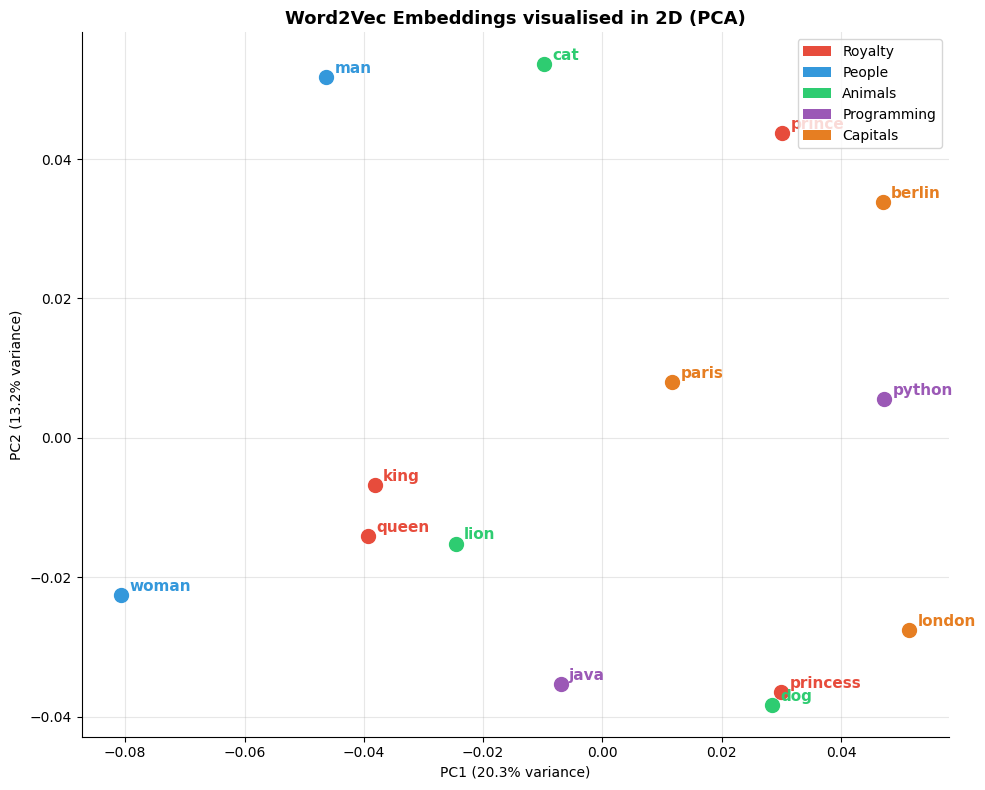

In [63]:
# Visualise Word Embeddings with PCA 
words_to_plot = [
    'king', 'queen', 'man', 'woman', 'prince', 'princess',
    'dog', 'cat', 'lion',
    'python', 'java',
    'paris', 'london', 'berlin'
]

vectors = np.array([model.wv[w] for w in words_to_plot if w in model.wv])
available_words = [w for w in words_to_plot if w in model.wv]

# Reduce to 2D with PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

# Colour groups
groups = {
    'Royalty':     ['king', 'queen', 'prince', 'princess'],
    'People':      ['man', 'woman'],
    'Animals':     ['dog', 'cat', 'lion'],
    'Programming': ['python', 'java'],
    'Capitals':    ['paris', 'london', 'berlin']
}
group_colors = {'Royalty': '#e74c3c', 'People': '#3498db',
                'Animals': '#2ecc71', 'Programming': '#9b59b6', 'Capitals': '#e67e22'}

fig, ax = plt.subplots(figsize=(10, 8))

for word, (x, y) in zip(available_words, coords):
    color = '#7f8c8d'
    for group, members in groups.items():
        if word in members:
            color = group_colors[group]
            break
    ax.scatter(x, y, color=color, s=100, zorder=3)
    ax.annotate(word, (x, y), textcoords='offset points',
                xytext=(6, 3), fontsize=11, fontweight='bold', color=color)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=legend_elems, loc='upper right')

ax.set_title('Word2Vec Embeddings visualised in 2D (PCA)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## Section 8: Deep Learning for NLP

Deep learning models can capture **sequential patterns** and long-range dependencies in text.

### Architectures
| Model | Key Idea |
|---|---|
| **RNN** | Processes tokens sequentially; has hidden state memory |
| **LSTM** | Extends RNN with gates (forget, input, output) to prevent vanishing gradients |
| **GRU** | Simplified LSTM with fewer parameters |
| **Transformer** | Attention mechanism — parallel, no recurrence (Section 9) |

We'll build a simple **LSTM text classifier** using PyTorch.

In [64]:
# Section 8 — LSTM Text Classifier (PyTorch)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# simple toy dataset 
positive_texts = [
    "i love this product it is amazing",
    "wonderful experience highly recommend",
    "fantastic quality excellent service",
    "great value and fast delivery",
    "absolutely brilliant love every aspect",
    "outstanding performance exceeded expectations",
    "perfect product works as described",
    "wonderful purchase very happy"
]
negative_texts = [
    "terrible product broke after one day",
    "horrible experience never buying again",
    "waste of money very disappointed",
    "poor quality bad customer service",
    "awful do not buy this product",
    "dreadful experience very unhappy",
    "defective product broke immediately",
    "completely useless and overpriced"
]

texts  = positive_texts + negative_texts
labels = [1]*len(positive_texts) + [0]*len(negative_texts)

# Build vocabulary 
all_words = [word for text in texts for word in text.split()]
vocab = {word: idx+2 for idx, (word, _) in enumerate(Counter(all_words).most_common())}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

MAX_LEN = 10

def text_to_ids(text, max_len=MAX_LEN):
    ids = [vocab.get(w, 1) for w in text.split()]
    # Pad or truncate to max_len
    ids = ids[:max_len] + [0] * max(0, max_len - len(ids))
    return ids

# Dataset class 
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = torch.tensor([text_to_ids(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.float)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

dataset    = TextDataset(texts, labels)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f' Dataset ready: {len(texts)} samples, vocab size: {len(vocab)}')

 Dataset ready: 16 samples, vocab size: 64


In [65]:
# LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc        = nn.Linear(hidden_dim, output_dim)
        self.sigmoid   = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)            # [batch, seq, embed]
        _, (hidden, _) = self.lstm(embedded)    # hidden: [1, batch, hidden]
        out = self.fc(hidden.squeeze(0))        # [batch, 1]
        return self.sigmoid(out).squeeze(1)

VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 16
HIDDEN_DIM  = 32
OUTPUT_DIM  = 1

model_lstm = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
optimizer  = optim.Adam(model_lstm.parameters(), lr=0.01)
criterion  = nn.BCELoss()

total_params = sum(p.numel() for p in model_lstm.parameters())
print(f' LSTM Model Architecture:')
print(model_lstm)
print(f'\nTotal parameters: {total_params:,}')

 LSTM Model Architecture:
LSTMClassifier(
  (embedding): Embedding(64, 16, padding_idx=0)
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 7,457


  Epoch 05/30 | Loss: 0.5998
  Epoch 10/30 | Loss: 0.0506
  Epoch 15/30 | Loss: 0.0027
  Epoch 20/30 | Loss: 0.0012
  Epoch 25/30 | Loss: 0.0008
  Epoch 30/30 | Loss: 0.0007


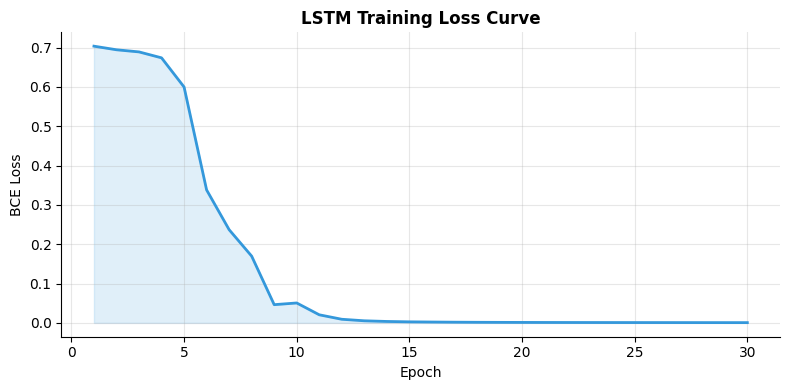

In [66]:
# training loop 
EPOCHS = 30
epoch_losses = []

model_lstm.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        preds = model_lstm(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}')

# Loss Curve 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS+1), epoch_losses, color='#3498db', linewidth=2)
ax.fill_between(range(1, EPOCHS+1), epoch_losses, alpha=0.15, color='#3498db')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('LSTM Training Loss Curve', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [67]:
# inference on new sentences 
model_lstm.eval()
test_sentences = [
    "this is an amazing product love it",
    "terrible quality very disappointed",
    "okay product nothing special"
]

print('🔮 LSTM Predictions:')
with torch.no_grad():
    for sent in test_sentences:
        ids    = torch.tensor([text_to_ids(sent)], dtype=torch.long)
        prob   = model_lstm(ids).item()
        label  = '😊 Positive' if prob > 0.5 else '😞 Negative'
        print(f'  "{sent}" → {label} ({prob:.3f})')

🔮 LSTM Predictions:
  "this is an amazing product love it" → 😊 Positive (1.000)
  "terrible quality very disappointed" → 😞 Negative (0.001)
  "okay product nothing special" → 😞 Negative (0.001)


---
## Section 9: Transformers

**Transformers** revolutionised NLP in 2017 with the landmark paper *"Attention Is All You Need"*.

### Key Concepts
| Concept | Description |
|---|---|
| **Self-Attention** | Each token attends to all other tokens : captures global context |
| **BERT** | Bidirectional Encoder : pre-trained on masked language modelling |
| **GPT** | Autoregressive decoder : pre-trained on next-token prediction |
| **Fine-tuning** | Adapt pretrained model to a downstream task (classification, QA...) |

### Hugging Face 🤗
The `transformers` library provides thousands of pretrained models with a simple API:
```python
from transformers import pipeline
classifier = pipeline('sentiment-analysis')
classifier('I love NLP!')
```

In [68]:
import warnings
warnings.filterwarnings('ignore')

from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(' Loading Hugging Face sentiment pipeline...')

sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True
)
print('model loaded!')

 Loading Hugging Face sentiment pipeline...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

model loaded!


In [69]:
#  run inference 
test_texts = [
    "The movie was absolutely breathtaking and emotional.",
    "I hated every second of this terrible film.",
    "It was just an average experience, nothing memorable.",
    "Transformers have completely revolutionised NLP — incredible technology!",
    "This product broke on the first day. Complete waste.",
    "Decent but not worth the hype surrounding it.",
    "One of the best experiences I have ever had!",
    "I would not recommend this to anyone."
]

hf_results = sentiment_pipeline(test_texts)

result_df = pd.DataFrame([
    {'Text': t[:60] + '...', 'Label': r['label'], 'Score': r['score']}
    for t, r in zip(test_texts, hf_results)
])

print('Transformer Predictions:')
print(result_df.to_string(index=False))

Transformer Predictions:
                                                           Text    Label    Score
        The movie was absolutely breathtaking and emotional.... POSITIVE 0.999877
                 I hated every second of this terrible film.... NEGATIVE 0.999596
       It was just an average experience, nothing memorable.... NEGATIVE 0.999703
Transformers have completely revolutionised NLP — incredible... POSITIVE 0.999826
        This product broke on the first day. Complete waste.... NEGATIVE 0.999787
               Decent but not worth the hype surrounding it.... NEGATIVE 0.988638
                One of the best experiences I have ever had!... POSITIVE 0.999853
                       I would not recommend this to anyone.... NEGATIVE 0.957748


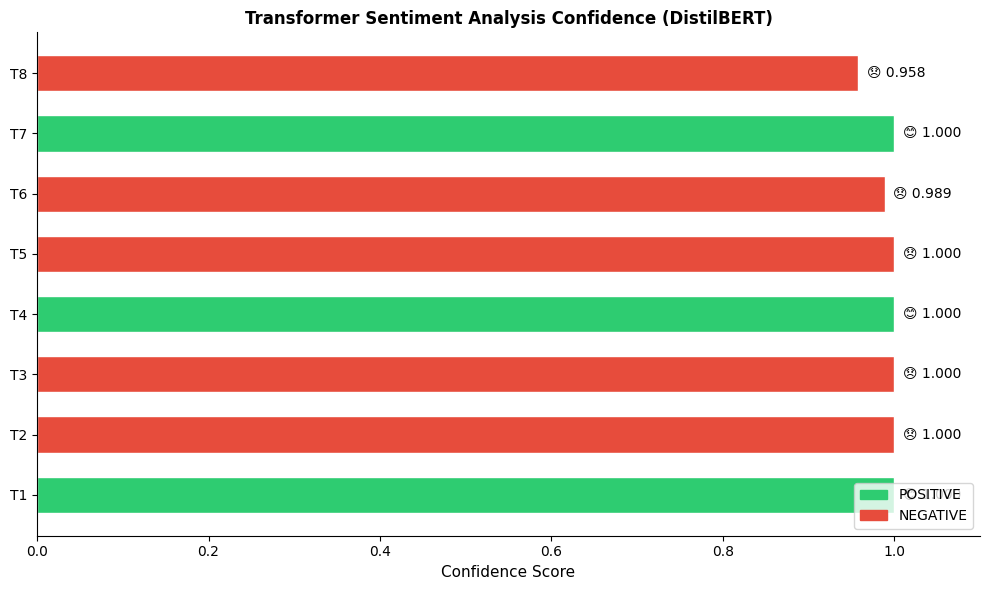

In [70]:
# Visualise
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#2ecc71' if l == 'POSITIVE' else '#e74c3c'
              for l in result_df['Label']]
bars = ax.barh(range(len(result_df)), result_df['Score'],
               color=bar_colors, edgecolor='white', height=0.6)

ax.set_yticks(range(len(result_df)))
ax.set_yticklabels([f'T{i+1}' for i in range(len(result_df))], fontsize=10)
ax.set_xlabel('Confidence Score', fontsize=11)
ax.set_title('Transformer Sentiment Analysis Confidence (DistilBERT)', fontweight='bold')
ax.set_xlim(0, 1.1)

for bar, score, label in zip(bars, result_df['Score'], result_df['Label']):
    emoji = '😊' if label == 'POSITIVE' else '😞'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{emoji} {score:.3f}', va='center', fontsize=10)

pos_patch = mpatches.Patch(color='#2ecc71', label='POSITIVE')
neg_patch = mpatches.Patch(color='#e74c3c', label='NEGATIVE')
ax.legend(handles=[pos_patch, neg_patch], loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

 Zero-Shot Classification (no fine-tuning needed!)


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

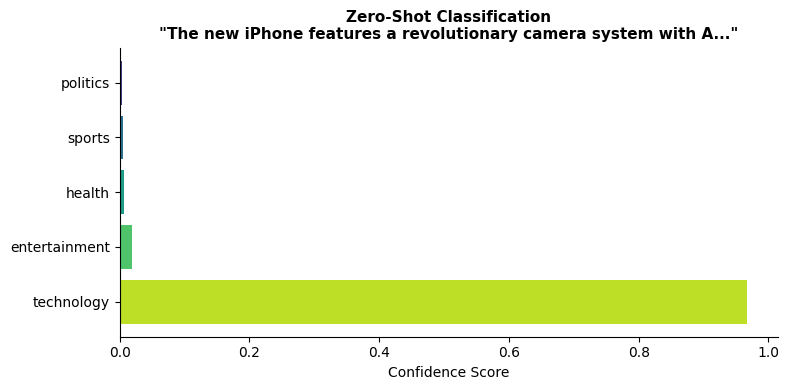

In [71]:
#  Bonus: Zero-shot Classification 
print(' Zero-Shot Classification (no fine-tuning needed!)')

zero_shot = pipeline('zero-shot-classification',
                     model='facebook/bart-large-mnli')

text = "The new iPhone features a revolutionary camera system with AI enhancements."
candidate_labels = ['technology', 'sports', 'politics', 'health', 'entertainment']

result = zero_shot(text, candidate_labels)

zs_df = pd.DataFrame({'Label': result['labels'], 'Score': result['scores']})

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(zs_df)))
ax.barh(zs_df['Label'], zs_df['Score'], color=colors[::-1])
ax.set_xlabel('Confidence Score')
ax.set_title(f'Zero-Shot Classification\n"{text[:60]}"', fontweight='bold', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

import numpy as np

---
## Section 10: 🚀 Mini NLP Project / End-to-End Text Classifier

### Objective
Build a **complete NLP pipeline** that:
1. Loads and explores raw text data
2. Preprocesses and cleans text
3. Extracts features (TF-IDF)
4. Trains and evaluates multiple models
5. Makes predictions on new text

### Dataset
We'll create a **multi-class news topic classifier** with 5 categories:
`Technology | Sports | Politics | Health | Entertainment`

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix)

# step 1: Create Dataset 
data = {
    'text': [
        # Technology
        "Apple released the new M3 chip with improved neural engine for machine learning tasks",
        "Google DeepMind published groundbreaking AI research on protein structure prediction",
        "Tesla autopilot uses computer vision and deep learning neural networks",
        "OpenAI released GPT-4 with multimodal capabilities for text and image understanding",
        "Microsoft Azure cloud platform expands AI and machine learning services globally",
        "Quantum computing breakthrough enables faster cryptographic calculations",
        "The new programming language Rust gains popularity for systems programming safety",
        "5G network rollout accelerates enabling faster mobile data and IoT connectivity",
        # Sports
        "The NBA finals game seven went into double overtime before the home team won",
        "World Cup qualifying matches conclude with surprising upsets in European brackets",
        "Olympic sprinter breaks world record in the hundred meter dash at championships",
        "Tennis grand slam winner dominates the clay court season with twenty victories",
        "Football transfer window opens with record-breaking deals for top strikers",
        "Marathon runner completes fastest ever time despite difficult weather conditions",
        "Swimming championships produce multiple gold medals for the home nation athletes",
        "Golf tournament final round sees dramatic comeback on the last three holes",
        # Politics
        "The senate voted on the new infrastructure bill after weeks of bipartisan debate",
        "Presidential election results show record voter turnout across all states",
        "European parliament passes landmark environmental regulations on carbon emissions",
        "United Nations security council convenes emergency meeting on regional conflict",
        "Prime minister announces new economic recovery plan amid rising inflation",
        "Supreme court ruling affects campaign finance laws and political donations",
        "International summit on climate change produces historic multilateral agreement",
        "Foreign minister visits neighboring countries to strengthen diplomatic relations",
        # Health
        "New cancer immunotherapy treatment shows remarkable results in clinical trials",
        "WHO reports declining rates of infectious diseases following vaccine campaigns",
        "Mental health awareness programs expand in schools and workplaces nationally",
        "Breakthrough diabetes medication reduces insulin dependence in type two patients",
        "Nutritionists recommend Mediterranean diet for cardiovascular health benefits",
        "Sleep research links chronic sleep deprivation to increased Alzheimer risk",
        "Gene therapy trial successfully treats rare inherited blood disorder patients",
        "Yoga and meditation programs reduce stress and anxiety in hospital patients",
        # Entertainment
        "The blockbuster superhero film breaks opening weekend box office records worldwide",
        "Grammy awards ceremony features surprise comeback performance by legendary artist",
        "Streaming platform releases critically acclaimed documentary series on climate",
        "Broadway musical wins multiple Tony awards for best direction and choreography",
        "Pop star announces world tour with sixty concerts across five continents",
        "Animated feature film wins Oscar for best picture amid industry celebration",
        "Video game launch breaks sales records with ten million copies in first week",
        "Television drama series finale draws record audience of fifty million viewers",
    ],
    'category': (['Technology']*8 + ['Sports']*8 +
                 ['Politics']*8 + ['Health']*8 + ['Entertainment']*8)
}

df_project = pd.DataFrame(data)
print(f' Dataset: {len(df_project)} articles, {df_project["category"].nunique()} categories')
print(df_project['category'].value_counts())

 Dataset: 40 articles, 5 categories
category
Technology       8
Sports           8
Politics         8
Health           8
Entertainment    8
Name: count, dtype: int64


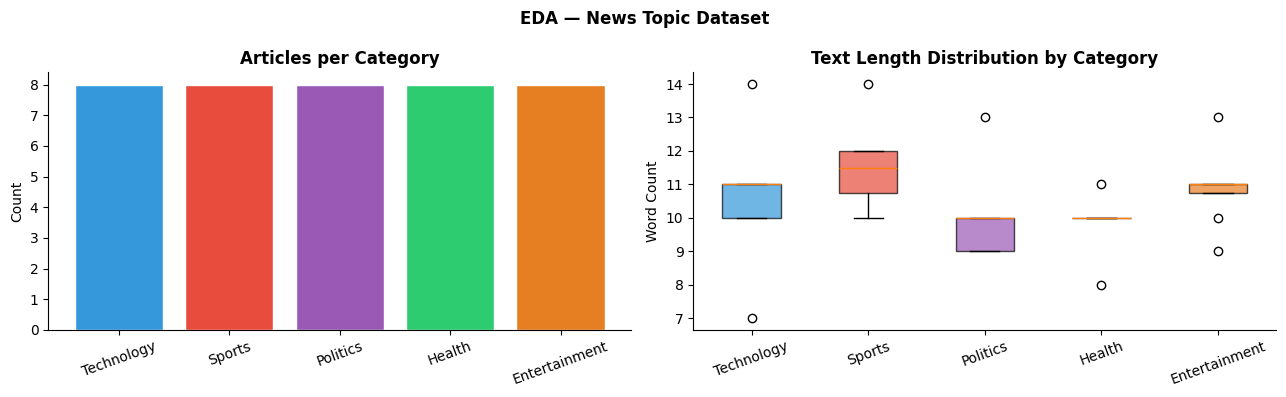

In [73]:
#  Step 2: Exploratory Data Analysis 
df_project['text_length'] = df_project['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Category distribution
cat_counts = df_project['category'].value_counts()
cat_colors = ['#3498db', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']
axes[0].bar(cat_counts.index, cat_counts.values, color=cat_colors, edgecolor='white')
axes[0].set_title('Articles per Category', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Text length boxplot
categories = df_project['category'].unique()
length_data = [df_project[df_project['category'] == c]['text_length'].values
               for c in categories]
bp = axes[1].boxplot(length_data, labels=categories, patch_artist=True)
for patch, color in zip(bp['boxes'], cat_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Text Length Distribution by Category', fontweight='bold')
axes[1].set_ylabel('Word Count')
axes[1].tick_params(axis='x', rotation=20)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('EDA — News Topic Dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [74]:
# step 3: Text Preprocessing Pipeline 
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """Full preprocessing pipeline: lower → depunct → tokenize → stopwords → lemmatize"""
    text = text.lower()                                           # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)                     # remove punct/numbers
    tokens = text.split()                                         # tokenize
    tokens = [t for t in tokens if t not in stop_words]          # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]           # lemmatize
    return ' '.join(tokens)

df_project['clean_text'] = df_project['text'].apply(preprocess_text)

print(' Preprocessing complete. Sample:')
for i in range(3):
    print(f'\n  RAW:   {df_project["text"].iloc[i][:80]}...')
    print(f'  CLEAN: {df_project["clean_text"].iloc[i][:80]}...')

 Preprocessing complete. Sample:

  RAW:   Apple released the new M3 chip with improved neural engine for machine learning ...
  CLEAN: apple released new chip improved neural engine machine learning task...

  RAW:   Google DeepMind published groundbreaking AI research on protein structure predic...
  CLEAN: google deepmind published groundbreaking ai research protein structure predictio...

  RAW:   Tesla autopilot uses computer vision and deep learning neural networks...
  CLEAN: tesla autopilot us computer vision deep learning neural network...


In [75]:
# step 4: Feature Extraction & Model Training
X = df_project['clean_text']
y = df_project['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF with bigrams
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

print(f'Train: {X_train_vec.shape} | Test: {X_test_vec.shape}')

# Train models
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         MultinomialNB(alpha=0.5),
    'SVM':                 LinearSVC(random_state=42, max_iter=2000)
}

project_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)
    acc    = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(
        clf, tfidf.transform(X), y, cv=5, scoring='accuracy'
    )
    project_results[name] = {
        'model': clf, 'y_pred': y_pred,
        'accuracy': acc, 'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f'  {name}: Accuracy={acc:.3f} | 5-Fold CV={cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Train: (30, 471) | Test: (10, 471)
  Logistic Regression: Accuracy=0.800 | 5-Fold CV=0.325 ± 0.127
  Naive Bayes: Accuracy=0.700 | 5-Fold CV=0.450 ± 0.187
  SVM: Accuracy=0.700 | 5-Fold CV=0.450 ± 0.187


 Best Model: Logistic Regression (Accuracy: 0.800)

 Classification Report:
               precision    recall  f1-score   support

Entertainment       1.00      1.00      1.00         2
       Health       1.00      0.50      0.67         2
     Politics       0.50      1.00      0.67         2
       Sports       1.00      0.50      0.67         2
   Technology       1.00      1.00      1.00         2

     accuracy                           0.80        10
    macro avg       0.90      0.80      0.80        10
 weighted avg       0.90      0.80      0.80        10



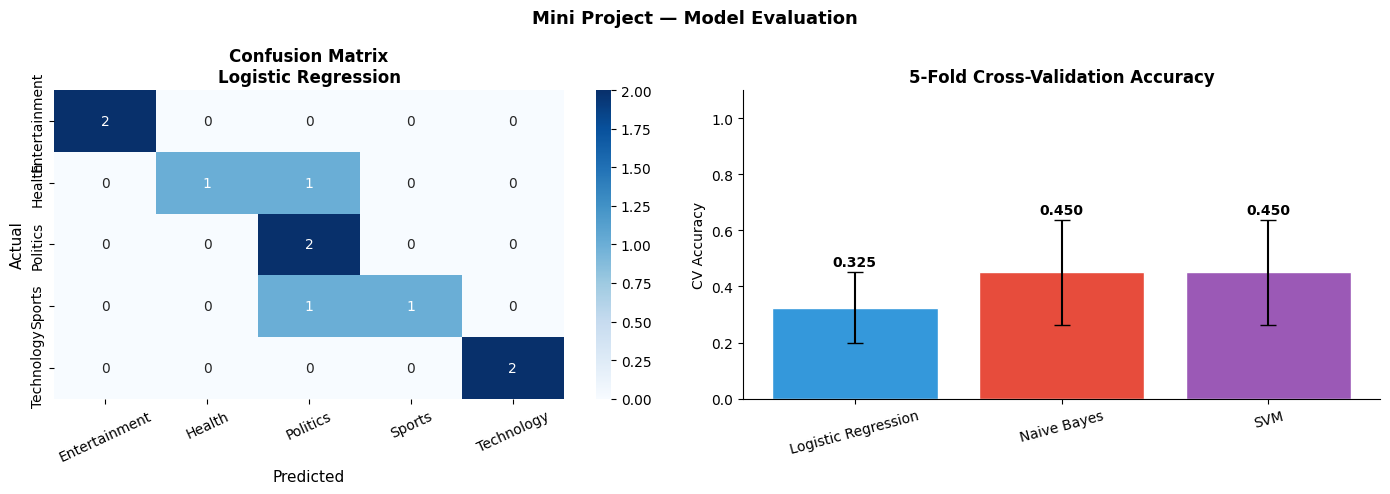

In [76]:
# step 5: Evaluation & Confusion Matrix
best_clf_name = max(project_results, key=lambda k: project_results[k]['accuracy'])
best_result   = project_results[best_clf_name]

print(f' Best Model: {best_clf_name} (Accuracy: {best_result["accuracy"]:.3f})')
print('\n Classification Report:')
print(classification_report(y_test, best_result['y_pred']))

# Confusion matrix
categories_list = sorted(y.unique())
cm = confusion_matrix(y_test, best_result['y_pred'], labels=categories_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories_list, yticklabels=categories_list, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_title(f'Confusion Matrix\n{best_clf_name}', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)

# CV comparison
names   = list(project_results.keys())
cv_means = [project_results[n]['cv_mean'] for n in names]
cv_stds  = [project_results[n]['cv_std']  for n in names]
axes[1].bar(names, cv_means, yerr=cv_stds, color=cat_colors[:3],
            capsize=6, edgecolor='white')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('CV Accuracy')
axes[1].set_title('5-Fold Cross-Validation Accuracy', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, m + s + 0.02, f'{m:.3f}', ha='center', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Mini Project — Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [77]:
# step 6: Prediction on Unseen Articles 
new_articles = [
    "Scientists develop new mRNA vaccine technology to combat influenza variants",
    "The football world cup final attracted over one billion television viewers globally",
    "New legislation proposes stricter regulations on social media data privacy",
    "Award winning director announces new film with an all star international cast",
    "Semiconductor chip shortage threatens global supply chain for consumer electronics"
]

# Preprocess and vectorize
new_clean   = [preprocess_text(a) for a in new_articles]
new_vectors = tfidf.transform(new_clean)

best_model = project_results[best_clf_name]['model']
predictions = best_model.predict(new_vectors)

print(f' Predictions using {best_clf_name}:')

cat_emojis = {'Technology': '💻', 'Sports': '⚽', 'Politics': '🏛️',
              'Health': '🏥', 'Entertainment': '🎬'}
for article, pred in zip(new_articles, predictions):
    emoji = cat_emojis.get(pred, '📄')
    print(f'{emoji} [{pred:<15}] {article[:65]}...')

 Predictions using Logistic Regression:
🏛️ [Politics       ] Scientists develop new mRNA vaccine technology to combat influenz...
⚽ [Sports         ] The football world cup final attracted over one billion televisio...
💻 [Technology     ] New legislation proposes stricter regulations on social media dat...
🎬 [Entertainment  ] Award winning director announces new film with an all star intern...
💻 [Technology     ] Semiconductor chip shortage threatens global supply chain for con...


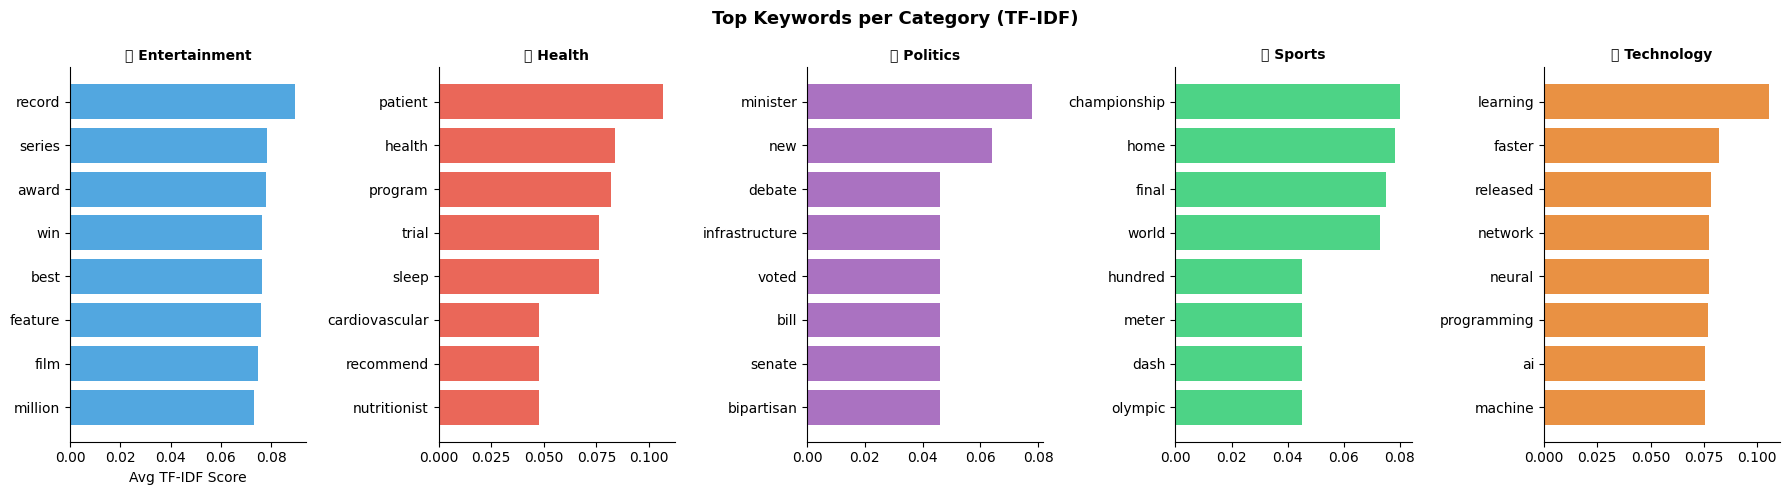

In [78]:
# ── Step 7: Top TF-IDF features per category ──────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Fit TF-IDF on all data
full_tfidf = TfidfVectorizer(ngram_range=(1,1), max_features=1000)
full_mat   = full_tfidf.fit_transform(df_project['clean_text'])
feat_names = full_tfidf.get_feature_names_out()

n_cats = len(categories_list)
fig, axes = plt.subplots(1, n_cats, figsize=(18, 5))

for ax, cat, color in zip(axes, categories_list, cat_colors):
    cat_mask  = df_project['category'] == cat
    cat_tfidf = full_mat[cat_mask.values].toarray().mean(axis=0)
    top_idx   = cat_tfidf.argsort()[-8:][::-1]
    top_words = [feat_names[i] for i in top_idx]
    top_vals  = cat_tfidf[top_idx]

    ax.barh(top_words[::-1], top_vals[::-1], color=color, alpha=0.85)
    ax.set_title(f'{cat_emojis.get(cat,"")} {cat}', fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axes[0]:
        ax.set_xlabel('Avg TF-IDF Score')

plt.suptitle('Top Keywords per Category (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎉 Congratulations!

You've completed the **NLP Practical Handbook**. Here's what you've learned:

| Section | Concepts |
|---|---|
| 1. Introduction | NLP definition, applications, pipeline |
| 2. Preprocessing | Tokenisation, stopwords, stemming, lemmatisation |
| 3. Representation | BoW, TF-IDF, N-grams |
| 4. Classification | LR, Naive Bayes, SVM + evaluation metrics |
| 5. Sentiment Analysis | VADER lexicon-based approach |
| 6. Topic Modeling | LDA |
| 7. Word Embeddings | Word2Vec, PCA visualisation |
| 8. Deep Learning | LSTM with PyTorch |
| 9. Transformers | Hugging Face DistilBERT, Zero-shot |
| 10. Mini Project | End-to-end multi-class news classifier |

### 📚 Next Steps
- **Fine-tune BERT** on your own classification task
- Try **Named Entity Recognition (NER)** with SpaCy
- Explore **Text Generation** with GPT-2
- Build a **Question Answering** system
- Deploy a model with **FastAPI** or **Gradio**

### 🔗 Resources
- [Hugging Face Docs](https://huggingface.co/docs)
- [NLTK Book](https://www.nltk.org/book/)
- [SpaCy Documentation](https://spacy.io/usage)
- [Scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html)

---
*Happy Learning! 🚀*